# 2D-Detector X-Ray Diffraction Synthetic Data Simulator
### Hyun Sang (Harrison) Park, Justin Wang

Some small notes: This is my first time doing Object Oriented Programming - one quite helpful text here was "Object Oriented Programming" by Peter Coad and Jill Nicola. A piece of advice in this book that was particularly helpful was this idea of an "I'm Alive" statement (page 3) specifically made for guiding object creation: Hi! I'm alive. I know my own ____ and I can ____ myself. Any "I'm Alive" statements have nothing to do with the code, and more so have to do with the fact that I am still learning and trying to follow better coding practices. They should help guide assign attributes and methods to certain items. 

This is the second iteration of an XRD code that I produced. While the first version of the code worked, it was written purely in procedural language, which is stupid and I hate myself. 

This code uses object oriented programming to simulate 2D XRD patterns. It defines a grain as an object with certain attributes that can project onto a detector. The grain's attributes educate the spot size and spot brightness as it projects onto the detector. In order to create larger 2D XRD patterns, it redefines the grain's size, strain, and orientation, then reprojects it onto the screen. It can do this with multiple grain types, as well as multiple atoms in different Wyckoff sites per grain. 

Some notes: because the Ewald sphere works by using the angular relationship between reciprocal space and real space, as long as the lattice parameter have the same units, it does not matter if those two have a different set of units than that of the detector (the inverse of the wavelength and the inverse of the lattice parameter are proportional to each other, and they produce a 2-theta angle that projects onto the detector from a distance from the center of the ewald sphere to the detector.)

### Dependencies 

In [47]:
import numpy as np
import math 
import matplotlib.pyplot as plt
import StructureFactors #Separate Python File to Include
import seaborn as sns
import os
import cv2

### Structure Factor and Copper Material Properties Placeholder
Temporary placeholder for Copper sample and structure factor calculations 

Importing Structure Factors, which have been calculated using standard complex-algebra equations for simplicity. Consider changing to using something such as Wyckhoff sites and space groups for more generalizability. 

In [48]:
CrystalStructure = input('what is the crystal structure?')
import StructureFactors
structure_factor_map = {
    'SC': StructureFactors.structure_factor_sc, 
    'FCC': StructureFactors.structure_factor_fcc,
    'BCC': StructureFactors.structure_factor_bcc,
    'HCP': StructureFactors.structure_factor_hcp,
}

if CrystalStructure in structure_factor_map:
    structure_factor_func = structure_factor_map[CrystalStructure]

'Baseline a, b, and c constants for an atomic scattering factor calculation done later on. Currently only set for copper. '
a_cu = [3.5493, 2.6412, 1.5170, 1.0243]
b_cu = [10.2825, 4.2944, 0.2615, 26.1476]
c_cu = [0.2776]

### Experiment Class

Class designed to house the basic information for the experiment. In our case, this refers to the experimental conditions within the MAXIMA at AIMD 

I'm Alive Statement: I am the experiment, I know my experimental conditions I can ... N/A, as this is just experimental conditions (grand initialization)

In [49]:
class Experiment: 
    def __init__(self, wavelength, sample): #consider moving the detector conditions to the detector object for code reusability ?
        self.wavelength = wavelength 
        self.material = sample
        self.inv_lambda = 1 / wavelength

class Sample: 
    def __init__(self, composition, sample_size): # this code will be used later for when I want to essentially be able to use the sample size to create some sense of how many grains I expect from a gauge volume. 
        self.composition = composition 

### Grain Class

Houses all the information related to the specific grain that is currently getting examined. Designed so that it can easily be iterated over multiple grains, which would allow us to have different numbers of grains of different types (secondary phases, materials, structures) where necessary. 

I'm Alive statement: I am the Grain class. I know my properties based on traits such as space group, Wyckoff positions, and lattice parameters. I can rotate and adjust my strain and size (specifically for polycrystalline simulations).

In [50]:
class Grain: 

    ''' grain size, lattice parameter, and wavelength need to have the same units, as they all convert into the reciprocal lattice. Any mistakes here will affect the 2theta values. Strain is unitless. '''    
    def __init__(self, size_average, size_variance, strain_average, strain_variance, aspect_ratio, lattice_parameter, experiment):
        self.size_average = size_average 
        self.size_variance = size_variance 
        self.aspect_ratio = aspect_ratio # Unused. 
        self.sphere_range = math.floor(1/ experiment.wavelength)
        self.lattice_parameter = lattice_parameter 
        self.strain_average = strain_average 
        self.strain_variance = strain_variance

        '''HKL indices are necessary as book-keeping for later calculations of structure factor''' 
        self.hkl_indices = [
            (h, k, l)
            for h in range(-self.sphere_range, self.sphere_range + 1)
            for k in range(-self.sphere_range, self.sphere_range + 1)
            for l in range(-self.sphere_range, self.sphere_range + 1)
        #    if h**2 + k**2 + l**2 <= self.sphere_range**2  # Limiting sphere (Ewald Sphere constraint)
        ]

        '''Actual reciprocal lattice coordinates in reciprocal space.'''
        self.reciprocal_lattice_vectors = np.array([
            (
                h / self.lattice_parameter,
                k / self.lattice_parameter,
                l / self.lattice_parameter
            )
            for h, k, l in self.hkl_indices
        ])

    '''I defined grain_size as a method instead of an attribute so that in later polycrstalline calculations, I could simply re-rotate a reciprocal lattice and change the size repeatedly in order to calculate projections. Currently not being used.'''

    def randomize_grain_size(self):
        return np.random.normal(grain.size_average, np.sqrt(grain.size_variance))  #Placeholder
    
    def randomize_grain_strain(self):
        return np.random.normal(grain.strain_average, np.sqrt(grain.strain_variance))  #Placeholder

    def randomize_rotation(self): 
        theta = np.radians(np.random.uniform(0, 360))  # rotate around z
        phi   = np.radians(np.random.uniform(0, 360))  # rotate around x

        """Returns the combined rotation matrix for given angles."""

        Rz = np.array([
            [np.cos(theta), -np.sin(theta), 0],
            [np.sin(theta),  np.cos(theta), 0],
            [0,              0,             1]
        ])
        
        Rx = np.array([
            [1,  0,           0          ],
            [0,  np.cos(phi), -np.sin(phi)],
            [0,  np.sin(phi),  np.cos(phi)]
        ])

        R =  Rx @ Rz  # Apply rotation around x first, then z
        
        self.reciprocal_lattice_vectors = np.array(self.reciprocal_lattice_vectors)        
        self.reciprocal_lattice_vectors = self.reciprocal_lattice_vectors @ R.T  # 

In [51]:
class EwaldSphere: 
    """
    I'm Alive! I am the EwaldSphere class
    I know my size and location
    I can project activated diffraction conditions out into all directions. I also know what the intensities of those diffracted points should be. 
    """
    def __init__(self, rotated_grain, experiment, tolerance) :
        self.radius = experiment.inv_lambda
        self.center = (-self.radius, 0, 0)
        self.tolerance = tolerance 
        self.distance_target =  (1/experiment.wavelength) 
        self.rotated_grain = rotated_grain
        #distances of reciprocal lattice vector tips of the grain from the center of the Ewald Sphere. consider erasing center[1] and center[2], as they will likely permanently be 0, and this would just raise computational overhead 
        
        self.distances_of_rlv_from_center = np.sqrt(
            (self.rotated_grain.reciprocal_lattice_vectors[:, 0] - self.center[0])**2 +
            (self.rotated_grain.reciprocal_lattice_vectors[:, 1] - self.center[1])**2 +
            (self.rotated_grain.reciprocal_lattice_vectors[:, 2] - self.center[2])**2
        )

    def filter_points (self):
        mask = (
            (self.distances_of_rlv_from_center >= self.distance_target - self.tolerance) &
            (self.distances_of_rlv_from_center  <= self.distance_target + self.tolerance))
        
        return self.rotated_grain.reciprocal_lattice_vectors[mask]
        

class Detector: #Essentially the Experiment
    '''
    I'm alive: I'm a detector class
    I know where I am relative to the Ewald Sphere. I know what is being projected onto me. 
    I know how to calculate all the 2thetas on myself. 
    I can instrumentally broaden all the points on myself. I do, however, use an intermediary objecct, defined later (point_on_detector), to store all the information about the broadened point itself. Honestly, this secondary object could probably be done within the Detector object itself I am just careful to do so in case this object becomes a little too unwieldy. 
    Projected_Points).
    '''
    def __init__ (self, ewald_sphere, Experiment, detector_width, detector_height, detector_distance, filtered_points):
        self.experiment = Experiment
        self.detector_width = detector_width
        self.detector_height = detector_height
        self.detector_distance = detector_distance
        self.ewald_sphere = ewald_sphere
        self.filtered_points = filtered_points 
        detector_corners = np.array([
            [detector_distance, -detector_width / 2, -detector_height / 2],
            [detector_distance, detector_width / 2, -detector_height / 2],
            [detector_distance, detector_width / 2, detector_height / 2],
            [detector_distance, -detector_width / 2, detector_height / 2],
        ])
        self.detector_x = [corner[0] for corner in detector_corners] + [detector_corners[0][0]]
        self.detector_y = [corner[1] for corner in detector_corners] + [detector_corners[0][1]]
        self.detector_z = [corner[2] for corner in detector_corners] + [detector_corners[0][2]]

        self.projected_points = []
        self.two_theta = []
            
    def project_points(self):
        filtered_points = self.ewald_sphere.filter_points()
        for point in filtered_points:
            # Extract the necessary components.
            xyz_coords = np.array(point[:3])   # x, y, z coordinates

            # Calculate the direction vector from the sphere center to the point.
            direction_vector = xyz_coords - self.ewald_sphere.center

            # Calculate the scale factor so that the point projects onto the plane at x = detector_distance.
            scale_factor = (self.detector_distance - self.ewald_sphere.center[0]) / direction_vector[0]

            # Calculate the projected point.
            projected_point = np.array(self.ewald_sphere.center) + scale_factor * direction_vector
            # Check if the projected point falls within the detector boundaries (y and z).
            if (
                -self.detector_width / 2  <= projected_point[1] <= self.detector_width / 2 and
                -self.detector_height / 2 <= projected_point[2] <= self.detector_height / 2
            ):
                self.projected_points.append(projected_point)

                two_theta_angle = math.atan((((projected_point[1])**2 + projected_point[2]**2)**0.5)/self.detector_distance)
                if two_theta_angle != 0:

                    self.projected_points.append(projected_point)
                    self.two_theta.append(two_theta_angle)

            return {
                "coordinate": np.array(self.projected_points), #defines the location of the projected point on the detector itself
                "two_theta": np.array(self.two_theta) # Calculates the 2theta angle that the point makes on the detector. 
            #if I want to be a little unwieldy, I can likely define the entirety of point_on_detector, including all broadening operations, here as well.
                }

        return np.array(self.projected_points)
    
'''

    I'm alive: I'm a point on detector class.
    I know where I am on the detector, what angle I am from the center (the 2theta angle), as well as how bright I am, and how wide I should be, based on inputs from both the grain, the material, and the detector.
    I know how to convolve this value across a single (or in rare cases, multiple) delta functions.

    I know which pixel I'm closest to? - rasterize the image. 

    create a grid that is at least 3x more resolved than the detector itself. Then use a blurring function with a 3x3 pixellation function as the convolution moves acros the detector? This pixellation - how important is it anyhow, especially when synchrotron detectors tend to be so large (megapixel) ?

    I take the detector as an input. At that iteration, the detector is an area where there exists a single delta function. All other points are intensities. Set the Delta function intensity to something very specific and large, something that existing intensities would never be at? Or set the delta function as a non-integer, such as 0.5. 

'''

class PointOnDetector :

    def atomic_scattering_factor (self, s, a, b, c):
        """
        Calculate the atomic scattering factor f(s) using atomic scattering factor coefficients.
        Parameters:
        -----------
        s : float
            Scattering vector magnitude?
        a : list of float
            List of amplitude coefficients [a1, a2, a3, a4].
        b : list of float
            List of exponential damping coefficients [b1, b2, b3, b4].
        c : float
            Constant term for the scattering factor at high s.

        Returns:
        --------
        float
            Atomic scattering factor f(s).
        """
        if len(a) != 4 or len(b) != 4:
            raise ValueError("Coefficients 'a' and 'b' must each have exactly 4 elements.")

        f_s = sum(a[i] * np.exp(-b[i] * s**2) for i in range(4)) + c
        return f_s
        
    def fwhm_to_sigma(fwhm):
        """
        Convert FWHM to standard deviation sigma for a 1D Gaussian.
        FWHM = 2 * sqrt(2 * ln(2)) * sigma
        """
        return fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))

    def bivariate_gaussian(x, y, amplitude, x0, y0, sigma_x, sigma_y):
        """
        Returns the 2D Gaussian value at each point in the meshgrid (x, y).
        No correlation term, so it factors into (x part) * (y part).
        """
        return amplitude * np.exp(-(
            ((x - x0)**2)/(2 * sigma_x**2) + ((y - y0)**2)/(2 * sigma_y**2)
        )) #I wonder if it would be necessary or helpful to apply a correction factor or intensity constant here
        
    def __init__ (self, grain, ewald_sphere, detector, shape_factor, x_y_coordinate, experiment, exposure_time):
        self.grain = grain
        self.wavelength = experiment.wavelength
        self.shape_factor = shape_factor
        self.ewald_sphere = ewald_sphere
        self.detector = detector
        self.wavelength = experiment.wavelength
        self.exposure_time = exposure_time 
        self.size = grain.randomize_grain_size()
        self.strain = grain.randomize_grain_strain()
        self.material = "material"#define grain material for use in the atomic scattering factor 
        self.hkl = grain.hkl_indices
        self.projected_points = detector.project_points()

        self.two_theta = np.radians((self.projected_points['two_theta'])) # check if this is radians or degrees 
        self.theta = self.two_theta / 2 
        self.lorentz =  {'transmission': 1 / np.sin(2 * self.two_theta), 'reflection': None}
        self.polarization = {"polarized": np.cos(self.two_theta)**2, "unpolarized" : (1 + np.cos(2 * self.two_theta)**2) / 2 }
        self.coordinate = x_y_coordinate

        '''check all equations here - there was some buffoonery switching between theta and two_theta, just need to make sure that's all correct '''

        self.B_size = (self.shape_factor * self.wavelength) / (self.size * np.cos(self.theta))
        # Broadening due to strain
        self.B_strain = self.strain * np.tan(self.theta)
        # Total broadening using quadratic sum
        self.B_total = np.sqrt(self.B_size**2 + self.B_strain**2)

        self.s = (np.sin(self.theta))/self.wavelength 
        self.f_atomic_scatter = self.atomic_scattering_factor (self.s, a_cu, b_cu, c_cu)
        self.structure_factor = structure_factor_func(self.grain.hkl_indices[0],self.grain.hkl_indices[1],self.grain.hkl_indices[2], self.f_atomic_scatter)
        self.structure_factor_conjugate = self.structure_factor.conjugate()

        self.total_intensity = self.structure_factor * self.structure_factor_conjugate * self.lorentz['transmission'] * self.polarization['unpolarized'] * self.exposure_time
        self.fwhm = self.B_total**2


        self.fwhm = 1 #Scherrer equation, strain, instrumental?
        self.intensity = self.lorentz * self.polarization * self.structure_factor * self.structure_factor.conj #figure this out later. 
        self.peak = 1

In [52]:
'''
Structure Factor Calculations: 
There are two ways of going about this. One would be to simply use the standard forms of structure factor calculations for known systems such as FCC, BCC, CsCl, Wurtzite, etc. 

The other would be to define space groups and fully calculate the structure factor from scratch. This would have more applicability to geo-materials people, but not as much functionality for materials discovery in the ceramics and/or metals space... SiC polytypes might benefit from this. 

232 space groups: 

what space group is it? 

Where are the atoms in this space group? 

need to create a full dictionary of every possible space group, and every possible wyckhoff position in those space groups. 

'''

'\nStructure Factor Calculations: \nThere are two ways of going about this. One would be to simply use the standard forms of structure factor calculations for known systems such as FCC, BCC, CsCl, Wurtzite, etc. \n\nThe other would be to define space groups and fully calculate the structure factor from scratch. This would have more applicability to geo-materials people, but not as much functionality for materials discovery in the ceramics and/or metals space... SiC polytypes might benefit from this. \n\n232 space groups: \n\nwhat space group is it? \n\nWhere are the atoms in this space group? \n\nneed to create a full dictionary of every possible space group, and every possible wyckhoff position in those space groups. \n\n'

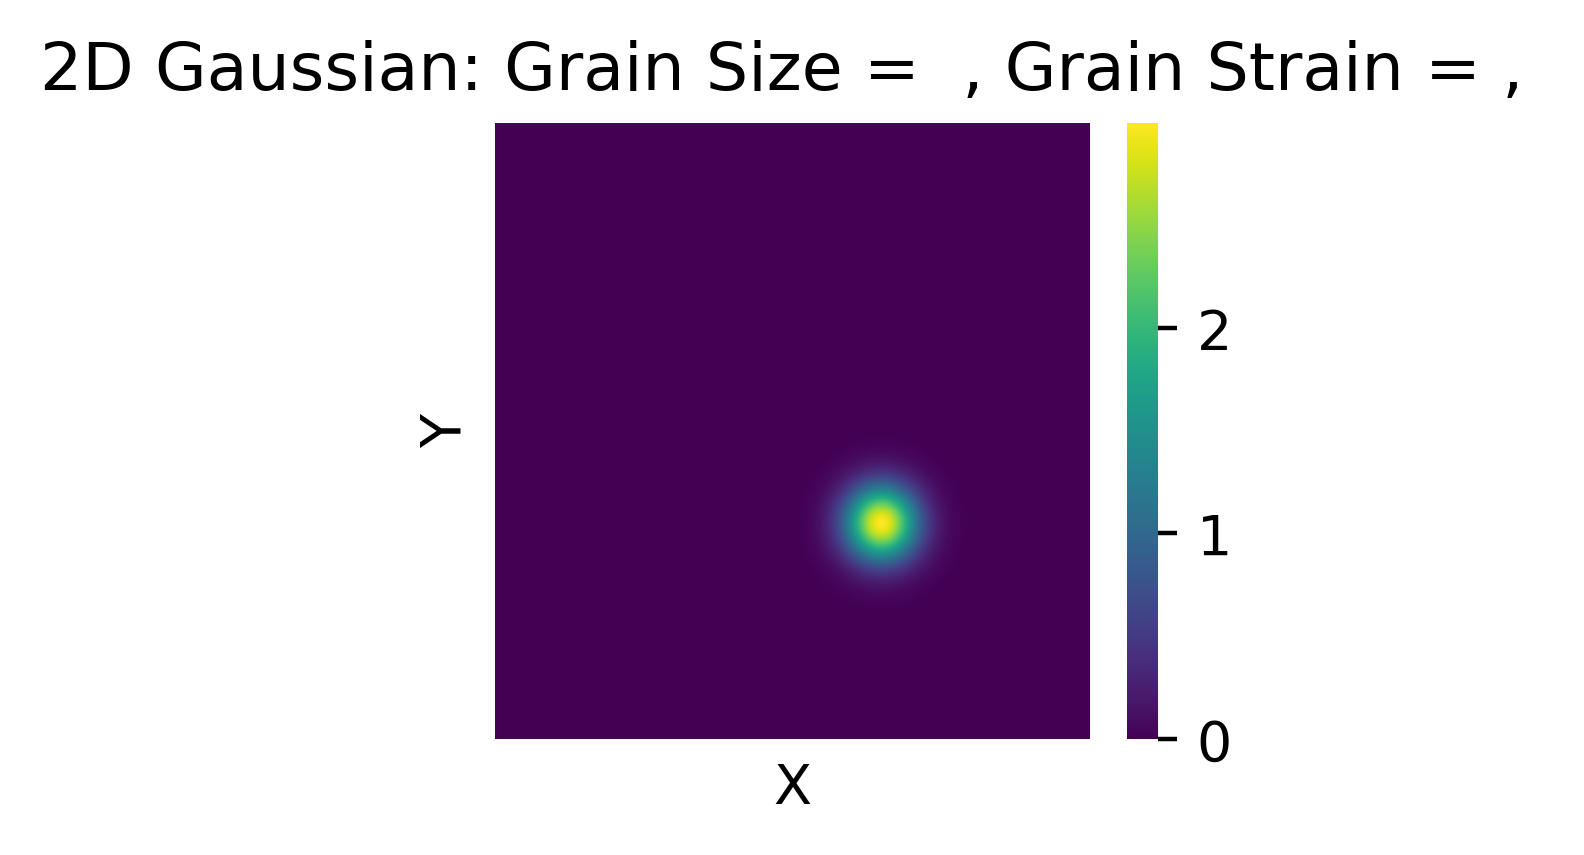

In [53]:
###############################################################################
# USER-DEFINED PARAMETERS
###############################################################################
# --- Gaussian parameters ---
def fwhm_to_sigma(fwhm):
    """
    Convert FWHM to standard deviation sigma for a 1D Gaussian.
    FWHM = 2 * sqrt(2 * ln(2)) * sigma
    """
    return fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))

def bivariate_gaussian(x, y, amplitude, x0, y0, sigma_x, sigma_y):
    """
    Returns the 2D Gaussian value at each point in the meshgrid (x, y).
    No correlation term, so it factors into (x part) * (y part).
    """
    return amplitude * np.exp(-(
        ((x - x0)**2)/(2 * sigma_x**2) + ((y - y0)**2)/(2 * sigma_y**2)
    ))  

FWHM = 10.0          # Full Width at Half Maximum (assuming same in x & y)
max_intensity = 3.0  # Peak amplitude
x_center = 65.0      # x-location of the Gaussian center
y_center = 65.0      # y-location of the Gaussian center

# --- Map extents ---
x_min, x_max = 0.0, 100.0
y_min, y_max = 0.0, 100.0


# --- Figure display settings ---
# Later: Match these resolution settings against the MAXIMA detector
fig_width = 2.4    # width in inches
fig_height = 2   # height in inches
dpi = 400        # dots per inch for the figure 
points_per_unit = 10

###############################################################################
# MAIN SCRIPT
###############################################################################
# 1. Convert FWHM -> sigma (assuming isotropic in x and y)
sigma = fwhm_to_sigma(FWHM)

# 2. Set up the meshgrid based on the chosen resolution
#    - number of points in each axis = (max-min)*points_per_unit
nx = int((x_max - x_min) * points_per_unit)
ny = int((y_max - y_min) * points_per_unit)

# Create coordinate arrays
x_vals = np.linspace(x_min, x_max, nx)
y_vals = np.linspace(y_min, y_max, ny)
X, Y = np.meshgrid(x_vals, y_vals)

# 3. Evaluate the 2D Gaussian on that grid
Z = bivariate_gaussian(X, Y, max_intensity, x_center, y_center, sigma, sigma)

# 4. Plot using Seaborn heatmap
#    - We specify figure size and dpi for controlling image resolution.
plt.figure(figsize=(fig_width, fig_height), dpi=dpi)

sns.heatmap(
    Z,
    xticklabels=False,  # Hide tick labels for clarity (optional)
    yticklabels=False,
    cmap='viridis'
)

plt.title(f"2D Gaussian: Grain Size =  , Grain Strain = , ")
plt.xlabel("X")
plt.ylabel("Y")

# 5. Show the result
plt.show()


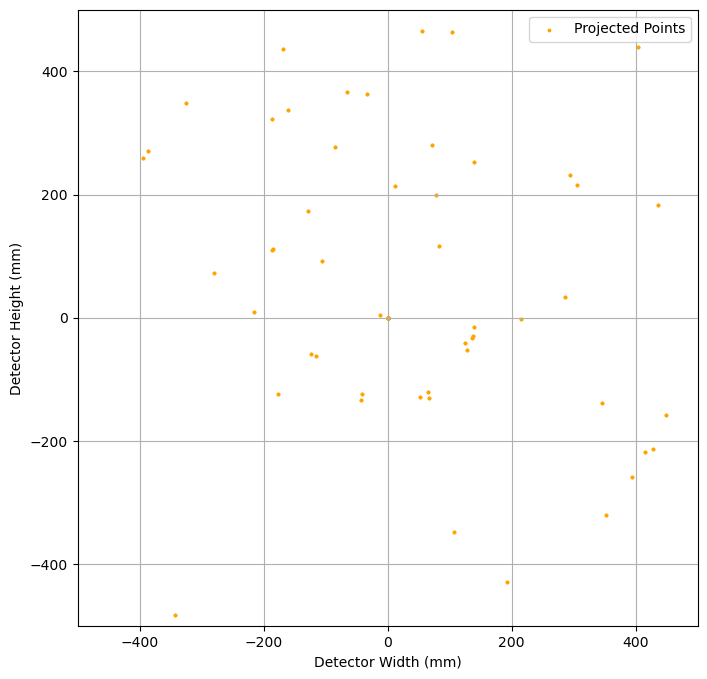

In [54]:
# Example Usage
num_grains = int(input('how many grains?'))
exp = Experiment(wavelength=0.154, sample="Arbitary")
grain = Grain(size_average=33500, size_variance=33062500, strain_average=0, strain_variance=0, aspect_ratio=1.5, lattice_parameter=0.361, experiment=exp)
coords_on_detector = []

for _ in range(num_grains):
    grain.randomize_rotation()
    grain.randomize_grain_size()
    grain.randomize_grain_strain()
    
    ewald = EwaldSphere(grain, exp, 0.03)
    filtered_points = ewald.filter_points()

    detector = Detector(ewald, exp, detector_width=1000, detector_height=1000, detector_distance=300, filtered_points = filtered_points)
    projected_points = detector.project_points()
    coords_on_detector.extend(projected_points["coordinate"])
coords_on_detector = np.array(coords_on_detector)


# Plot
if coords_on_detector is not None and len(coords_on_detector) > 0:
    projected_points = np.array(projected_points)
    x_coords = coords_on_detector[:, 1]
    y_coords = coords_on_detector[:, 2]
    fig, ax = plt.subplots(figsize=(8, 8))  # Create figure and axis
#    ax.set_facecolor('#d6fffe')  # Pale blue background for the graph (axes)
    plt.scatter(x_coords, y_coords, c='orange', s = 3, label="Projected Points")
    plt.xlim(-detector.detector_width / 2, detector.detector_width / 2)
    plt.ylim(-detector.detector_height / 2, detector.detector_height / 2)  
    plt.xlabel("Detector Width (mm)")
    plt.ylabel("Detector Height (mm)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No projected points to display.")


In [55]:
#Testing Ground for normal distributions 
num_grains = int(input('how many grains?'))
exp = Experiment(wavelength=0.154, sample="Arbitary")
grain = Grain(size_average=33500, size_variance=33062500, strain_average=0, strain_variance=0, aspect_ratio=1.5, lattice_parameter=0.361, experiment=exp)


for _ in range(num_grains):
    grain.randomize_rotation()
    grain.randomize_grain_size()
    grain.randomize_grain_strain()
    ewald = EwaldSphere(grain, exp, 0.03)
    filtered_points = ewald.filter_points()
    detector = Detector(ewald, exp, detector_width=1000, detector_height=1000, detector_distance=300, filtered_points = filtered_points)
 
    point = PointOnDetector(grain = grain, ewald_sphere = ewald, detector = detector, shape_factor = 0.9, x_y_coordinate = x_y_coordinate, experiment = exp, exposure_time = 10)

NameError: name 'x_y_coordinate' is not defined

In [624]:
# # Example Usage
# num_grains = int(input('how many grains?'))
# exp = Experiment(wavelength=0.154, sample="Arbitary")
# grain = Grain(size_average=10, size_variance=4, strain_average=10, strain_variance=4, aspect_ratio=1.5, lattice_parameter=0.361, experiment=exp)
# points_on_detector = []

# for _ in range(num_grains):
#     grain.randomize_rotation()
#     grain.randomize_grain_size()
#     grain.randomize_grain_strain()
#     ewald = EwaldSphere(grain, exp, 0.03)
#     filtered_points = ewald.filter_points()
#     detector = Detector(ewald, exp, detector_width=1000, detector_height=1000, detector_distance=300, filtered_points = filtered_points)
#     projected_points = detector.project_points()
#     points_on_detector.extend(projected_points["coordinate"])

# points_on_detector = np.array(points_on_detector)


# # Plot
# if points_on_detector is not None and len(points_on_detector) > 0:
#     projected_points = np.array(projected_points)
#     x_coords = points_on_detector[:, 1]
#     y_coords = points_on_detector[:, 2]
#     fig, ax = plt.subplots(figsize=(8, 8))  # Create figure and axis
# #    ax.set_facecolor('#d6fffe')  # Pale blue background for the graph (axes)
#     plt.scatter(x_coords, y_coords, c='orange', s = 3, label="Projected Points")
#     plt.xlim(-detector.detector_width / 2, detector.detector_width / 2)
#     plt.ylim(-detector.detector_height / 2, detector.detector_height / 2)  
#     plt.xlabel("Detector Width (mm)")
#     plt.ylabel("Detector Height (mm)")
#     plt.legend()
#     plt.grid(True)
#     plt.show()
# else:
#     print("No projected points to display.")

# x_coords = []
# y_coords = []
# for i in range(num_grains):
#     grain.randomize_rotation()
#     ewald = EwaldSphere(grain, exp, 0.03)
#     reciprocal_lattice = grain.reciprocal_lattice_vectors
#     filtered_points = ewald.filter_points()

#     fig = plt.figure(figsize=(18, 6))
    
#     ax1 = fig.add_subplot(131, projection='3d')
#     ax1.scatter(reciprocal_lattice[:, 0], reciprocal_lattice[:, 1], reciprocal_lattice[:, 2], c='b', s = 5)
#     ax1.set_title("Reciprocal Space and Ewald Sphere")

#     elevation = 0  # Elevation angle in degrees (vertical rotation)
#     azimuth = 269# Azimuth angle in degrees (horizontal rotation)
#     ax1.view_init(elev=elevation, azim=azimuth)
    
#     ax2 = fig.add_subplot(132, projection='3d')
#     ax2.scatter(reciprocal_lattice[:, 0], reciprocal_lattice[:, 1], reciprocal_lattice[:, 2], c='b', s= 10)
#     # Plot the detector rectangle
#     detector_corners = np.array([
#         [detector.detector_distance, -detector.detector_width / 2, -detector.detector_height / 2],
#         [detector.detector_distance, detector.detector_width / 2, -detector.detector_height / 2],
#         [detector.detector_distance, detector.detector_width / 2, detector.detector_height / 2],
#         [detector.detector_distance, -detector.detector_width / 2, detector.detector_height / 2],
#     ])
#     detector_x = [corner[0] for corner in detector_corners] + [detector_corners[0][0]]
#     detector_y = [corner[1] for corner in detector_corners] + [detector_corners[0][1]]
#     detector_z = [corner[2] for corner in detector_corners] + [detector_corners[0][2]]
#     ax2.plot(detector_x, detector_y, detector_z, color='red', label='Detector')

#     detector = Detector(ewald, exp, detector_width=1000, detector_height=1000, detector_distance=300, filtered_points=filtered_points)
#     projected_points_dict = detector.project_points()
#     projected_points = np.array(projected_points_dict["coordinate"]) if "coordinate" in projected_points_dict else np.array([])
    
#     # Plot the projections on the detector
#     if len(projected_points) > 0:
#         ax2.scatter(detector.detector_distance, projected_points[:, 0], projected_points[:, 1], c='orange', label='Projections on Detector', s=30)

#     # Draw lines from sphere center through filtered points to detector
#     for point, proj in zip(filtered_points, projected_points):
#         ax2.plot([ewald.center[0], point[0], proj[0]],
#                 [ewald.center[1], point[1], proj[1]],
#                 [ewald.center[2], point[2], proj[2]], color='gray', alpha=0.5)
    
#     ax2.set_xlabel("X (mm)")
#     ax2.set_ylabel("Y (mm)")
#     ax2.set_zlabel("Z (mm)")
#     ax2.set_title("Reciprocal Space Projection on Detector")
#     ax2.legend()


#     ax2.set_title("Reciprocal Space Projection on Detector")
#     ax2.view_init(elev=elevation, azim=azimuth)

#     detector_points = projected_points 

#     if detector_points.shape != 0:
#         if detector_points.ndim == 1:
#             detector_points = detector_points.reshape(-1, 3)  # Assuming it should have 3 columns
        
#         x_coords.extend(detector_points[:, 1])
#         y_coords.extend(detector_points[:, 2])

#     ax3 = fig.add_subplot(133)
#     ax3.scatter(x_coords, y_coords, c='orange', s = 3, label="Projected Points")

#     ax3.set_xlim(-detector.detector_width / 2, detector.detector_width / 2)

#     ax3.set_ylim(-detector.detector_height / 2, detector.detector_height / 2)  
#     ax3.set_title(f"2D Detector View: Grain {i+1}")
#     ax3.set_aspect('equal')
#     output_dir = os.path.expanduser("~/Desktop/grain_frames")
#     os.makedirs(output_dir, exist_ok=True)
#         # Save frame
#     frame_path = os.path.join(output_dir, f"frame_{i:04d}.png")
#     plt.savefig(frame_path)
#     plt.close(fig)

#     plt.show()


# # Create video from frames

# video_path = os.path.expanduser("~/Desktop/grains_projection.mp4")
# frame_files = sorted([os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith(".png")])

# # Get frame size
# frame = cv2.imread(frame_files[0])
# height, width, layers = frame.shape

# # Use the highest FPS needed
# fps = 1
# out = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

# for frame_file in frame_files:
#     frame = cv2.imread(frame_file)
#     out.write(frame)

# out.release()
# print(f"Video saved at: {video_path}")
